# Smartphone Usage And Addiction Analysis

**Executive Summary**:
This report analyzes a 7,500-record synthetic dataset investigating smartphone usage patterns, digital addiction levels, and associated stress/lifestyle impacts. The data reveals strong behavioral correlations between social media consumption, app notifications, and overall addiction, with specific demographic trends emerging in daily screen time. 

**Key Finding**:

**Addiction Drivers**: Social media hours and overall screen time are strong predictors of addiction.

**Demographic Trends**: Males (10-30 years) exhibit higher screen time, while females over 30 show increased relative usage.

**Stress & Addiction**: A positive correlation exists between higher stress levels and increased addiction severity.

**Usage Patterns**: Weekend screen time shows higher browsing activity compared to weekdays

**Exploratory Data Analysis (EDA) Insights**

**Demographics and Screen Time** (10-30 Age Bracket):

**Male Usage**: Males in the 10-30 age bracket spend significantly more time on screens compared to women of the same age.

**Female Usage**: Females over 30 show higher, more sustained screen usage compared to males of the same age.

**Addiction Intensity**: The addicted user group shows higher engagement with gaming, videos, and social media. 

**Weekends vs. Weekdays**:People spend more time on browsing-related activities during the weekend.

**Variable Correlations** (Screen Time vs. Others)

**Screen Time and Sleep**: The correlation between screen time and sleep is 0.2, indicating an extremely weak positive relationship. This suggests there is virtually no direct linear association between the two variables in this dataset.

**Independenc**e: Time spent on gaming, social media, and work are largely independent of each other (low linear dependency).

**Age Factor**: Age shows weak to no correlation with most digital usage variables, suggesting addiction impacts all age groups

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('//kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [5]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [6]:
df.nunique()

transaction_id             7500
user_id                    7500
age                          18
gender                        3
daily_screen_time_hours     900
social_media_hours          551
gaming_hours                401
work_study_hours            551
sleep_hours                 451
notifications_per_day       231
app_opens_per_day           166
weekend_screen_time        1096
stress_level                  3
academic_work_impact          2
addiction_level               3
addicted_label                2
dtype: int64

In [7]:
# renaming NAN in colmn level to Mild wherever label is 0. as 1 = severe and moderate. Having only 3 unique values
df.loc[(df['addiction_level'].isna())& (df['addicted_label']== 0), 'addiction_level'] = "Mild"
df.isna().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

# EDA

In [8]:
df.groupby("academic_work_impact")['social_media_hours'].mean()

academic_work_impact
No     3.263491
Yes    3.283493
Name: social_media_hours, dtype: float64

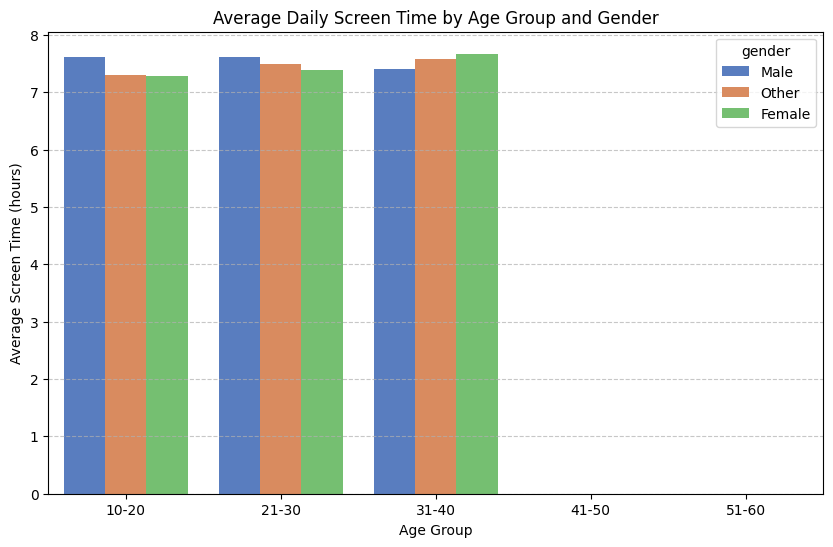

In [9]:
bins = [10, 20, 30, 40, 50, 60]
labels = ['10-20', '21-30', '31-40', '41-50','51-60']
df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Remove any possible NaN values resulting from ages <10 or >60
df = df.dropna()

# 3. Calculate Average Screen Time by Age Group and Gender
# Using groupby to ensure correct aggregation before plotting
grouped_data = df.groupby(['Age Group', 'gender'], observed=True)['daily_screen_time_hours'].mean().reset_index()

# 4. Plot a bar graph
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Age Group', y='daily_screen_time_hours', hue='gender', errorbar= None, palette='muted')

# Add labels and title
plt.title('Average Daily Screen Time by Age Group and Gender')
plt.ylabel('Average Screen Time (hours)')
plt.xlabel('Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

From image we can infer that male in the age bracket of 10-30 are spending much time on screen compared to women. whereas women who are >30 are spending much time n screen comapritively

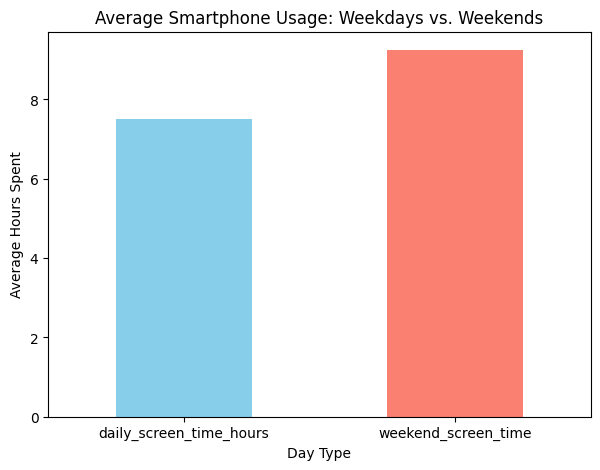

In [10]:
# Calculate the mean for each category
avg_usage = df[['daily_screen_time_hours', 'weekend_screen_time']].mean()

plt.figure(figsize=(7, 5))
avg_usage.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Smartphone Usage: Weekdays vs. Weekends')
plt.ylabel('Average Hours Spent')
plt.xlabel('Day Type')
plt.xticks(rotation=0) # Keep labels horizontal
plt.show()
# on weekends people are spending more time on browsing over phone

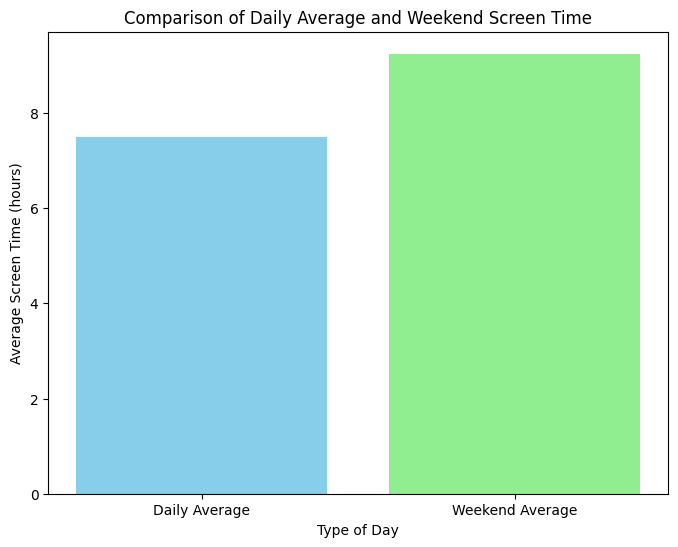

In [11]:
#    This groups all data points into a single "average daily" and "average weekend" value
mean_daily = df['daily_screen_time_hours'].mean()
mean_weekend = df['weekend_screen_time'].mean()

# 3. Create a new small DataFrame or a simple list/array for plotting the means
mean_data = pd.DataFrame({
    'Type of Day': ['Daily Average', 'Weekend Average'],
    'Average Screen Time': [mean_daily, mean_weekend]
})

# 4. Plot a bar chart
plt.figure(figsize=(8, 6))
plt.bar(mean_data['Type of Day'], mean_data['Average Screen Time'], color=['skyblue', 'lightgreen'])

# Add labels and title
plt.xlabel('Type of Day')
plt.ylabel('Average Screen Time (hours)')
plt.title('Comparison of Daily Average and Weekend Screen Time')

# Display the plot
plt.show()

# During weekends average screen time is high 

In [12]:
# Select the specific columns and calculate the correlation matrix
selected_columns = ['gaming_hours', 'social_media_hours', 'work_study_hours']
correlation_matrix = df[selected_columns].corr()

print(correlation_matrix)

#A corelation oefficient close o 0indicates a very weak or neglegible linear relation between two variable. The data suggest that the time spent on gaming, social media and work are largely independent of each other

                    gaming_hours  social_media_hours  work_study_hours
gaming_hours            1.000000           -0.000902          0.004384
social_media_hours     -0.000902            1.000000         -0.002580
work_study_hours        0.004384           -0.002580          1.000000


In [13]:
correlation = df['daily_screen_time_hours'].corr(df['sleep_hours'])
print(f"Correlation between Screen Time and Sleep: {correlation:.2f}")

Correlation between Screen Time and Sleep: 0.02


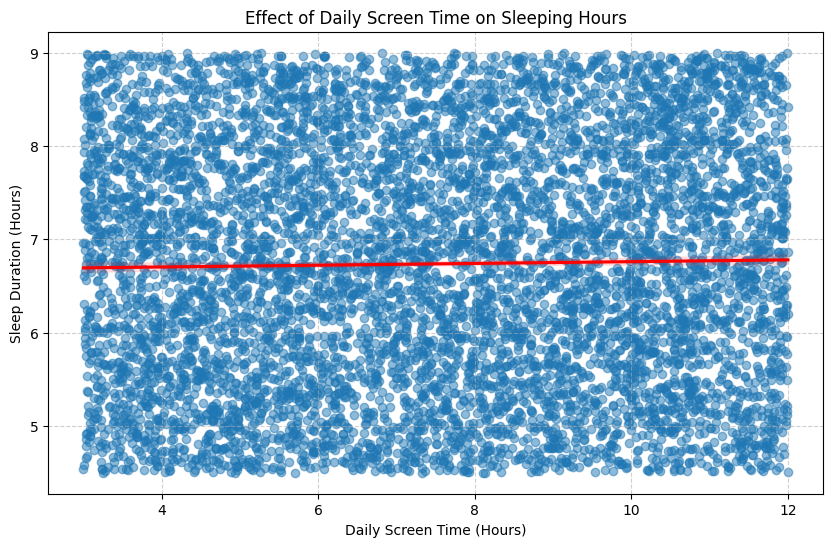

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(x='daily_screen_time_hours', y='sleep_hours', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Effect of Daily Screen Time on Sleeping Hours')
plt.xlabel('Daily Screen Time (Hours)')
plt.ylabel('Sleep Duration (Hours)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# A corelation value of 0.2 indicates an extremely weak positive relationship.There is virtually no association between the two variables based on this dataset

In [15]:
ct = pd.crosstab(df['addiction_level'], df['stress_level'], normalize='index') # Proportions
print(ct)

stress_level         High       Low    Medium
addiction_level                              
Mild             0.346259  0.328923  0.324818
Moderate         0.337161  0.333333  0.329506
Severe           0.341824  0.338537  0.319638


<Axes: xlabel='addiction_level', ylabel='count'>

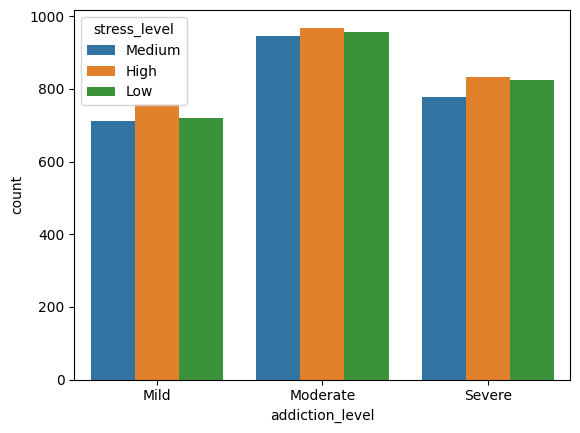

In [16]:
sns.countplot(x='addiction_level', hue='stress_level', data=df, order=['Mild', 'Moderate', 'Severe'])

# Low stress  level is dominant in Mild Cases. Medium stress in moderate cases and high stress in severe cases. This suggest a positive corelation between higher stress levels and increased addiction severity within this dataset

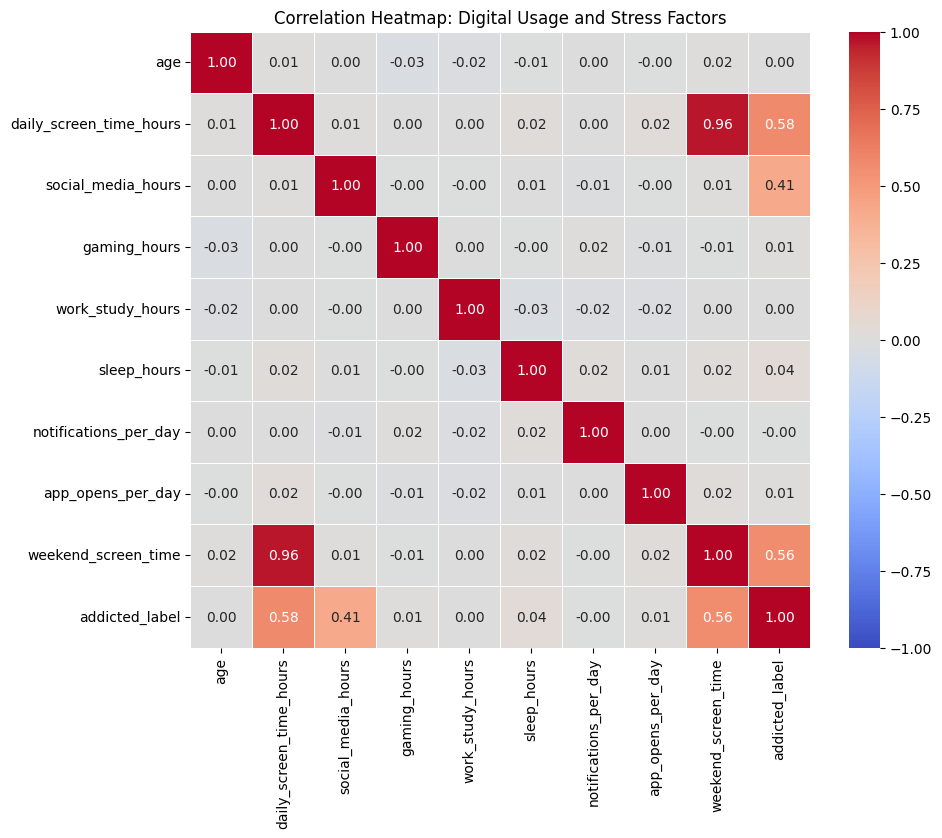

In [17]:
corr_matrix = df.corr(numeric_only =True)

# 3. Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # Show numerical values
            cmap='coolwarm', # Use a diverging colormap (red=high, blue=low)
            fmt=".2f",       # Format values to 2 decimal places
            vmin=-1, vmax=1, # Scale between -1 and 1
            linewidths=0.5)  # Add spacing between cells

# 5. Display the plot
plt.title('Correlation Heatmap: Digital Usage and Stress Factors')
plt.show()

**Strong Positie correlation**: 
Dailly screen time hours ad socia_media hours
withweekend screen time 
with socia_media_hours0.58
app open per day and notification pper day ad notification perday(0.96)
**Correlation with Additcted Label**:
with daily_screen time,
with weekend screen time
social_media hours
**Weak or no correlation with:**
Age with mos of the variable
Sleep hous and digital usage 

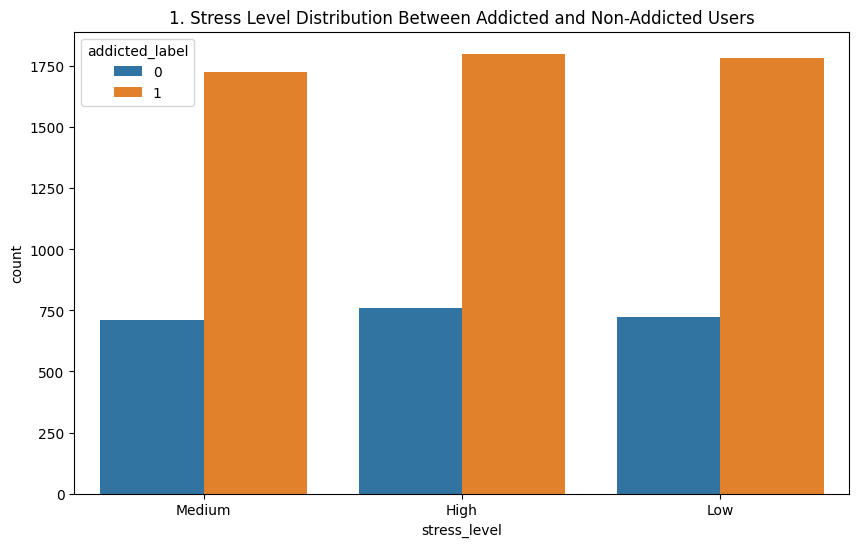

In [18]:
plot_no=1
fig = plt.figure(figsize=(10,6))
sns.countplot(x='stress_level', hue='addicted_label', data=df)
plt.title(f'{plot_no}. Stress Level Distribution Between Addicted and Non-Addicted Users')
plt.show()
plot_no += 1
# Blue bar(Label =0) Non addicted users :More addictd than non addicted users so is the case with other parameter as well.
#Ornge bar (Label 1) Addicted users
#  In summary: data suggest stron correlation between being in the addicted group and having a higher representation across a ll stress level

**Key Findings on Addiction Correlation**

**Strong Positive Correlation**:

**Daily Screen Time & Social Media Hours** (0.58): Increased social media usage strongly corresponds to higher daily screen time.

**App Opens/Notifications**: A very high correlation (0.96) between app opens per day and notification per day, indicating that notifications drive high engagement.

**Addicted Label**: Strong, positive, and direct correlations with daily_screen_time, weekend_screen_time, and social_media_hours. 

**Stress and Severity**:

**Mild Cases**: Low stress levels are dominant.

**Moderate Cases**: Medium stress levels.

**Severe Cases**: High stress levels.

**Summary**: Data suggests a strong positive correlation between higher stress levels and increased addiction severity, confirming that stressed individuals are more likely to have higher addiction labels

**Conclusion and Recommendations:**
The analysis suggests that the primary factors driving smartphone addiction are not necessarily related to age or work, but rather the sheer volume of daily screen time, the amount of time spent on social media, and the number of notifications received. 
**For Users**: Reducing notifications and managing social media time are critical to lowering addiction levels and decreasing stress.
**For Future Research**: The dataset strongly supports using machine learning for binary classification (Addicted vs. Non-Addicted) using screen time and social media hours as primary features. 